# M11: HC vs. protan vs. deutan SSVEP comparison

`PLANssveps.md` M11: same structure as `13_hc_vs_pd.ipynb`, three-way (HC/protan/deutan) instead of two-way, with all three pairwise subject-level comparisons.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
import pingouin as pg

import analysis
import permutation
import plotting

runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()
metadata_df = analysis.load_metadata()
troughs_df = pd.read_csv('../files/subject_troughs.csv')
SESSION = 1

categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

## Response grids, side by side

Raw, then percent change.

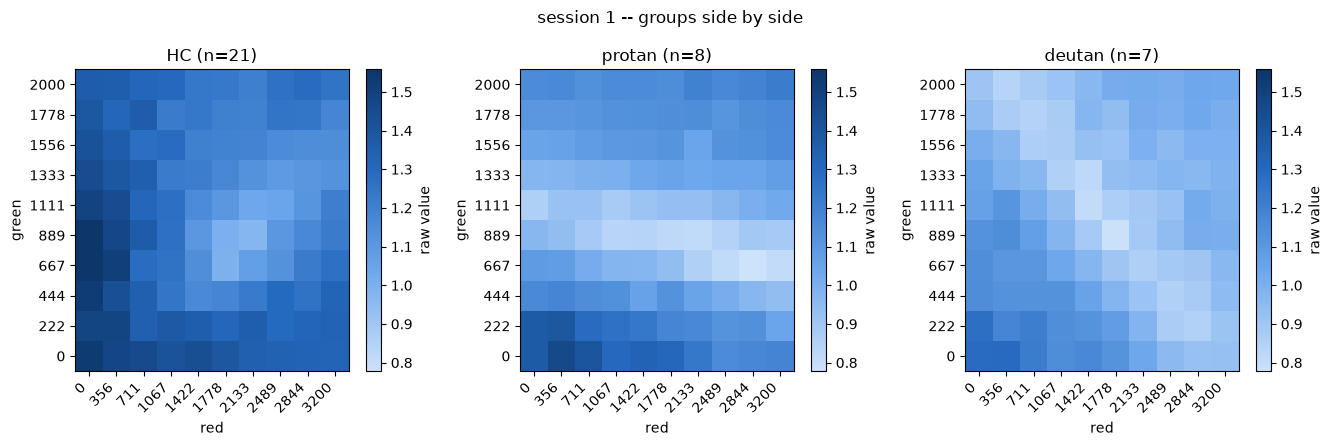

In [2]:
plotting.plot_groups_side_by_side(runmap_df, baselines_df, metadata_df, SESSION, categories, normalize=None);

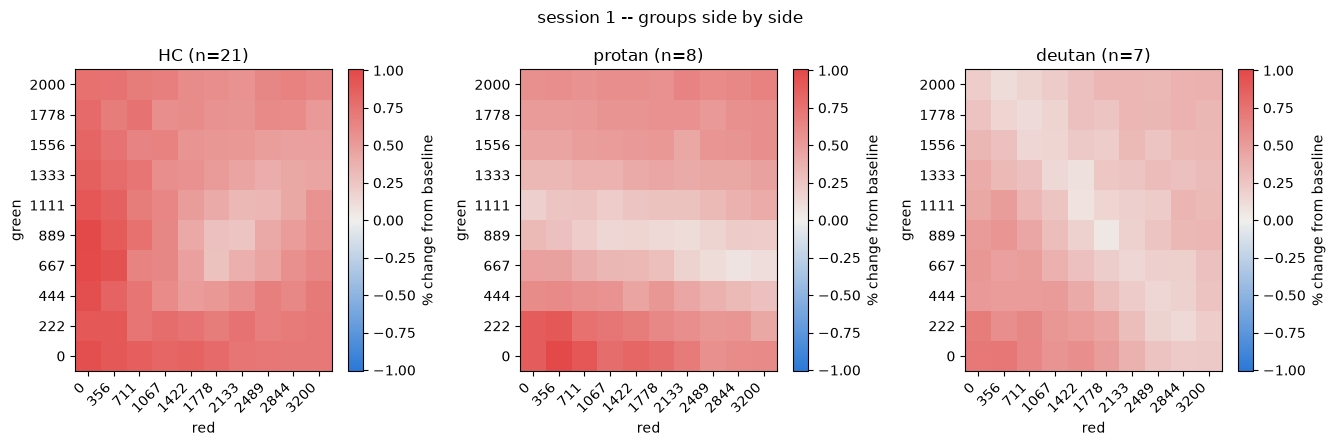

In [3]:
plotting.plot_groups_side_by_side(runmap_df, baselines_df, metadata_df, SESSION, categories, normalize=analysis.DEFAULT_NORMALIZE);

## Difference grids: the three pairwise comparisons

HC-protan, HC-deutan, protan-deutan -- percent change (the primary outcome measure); raw versions follow the same call with `normalize=None` if needed.

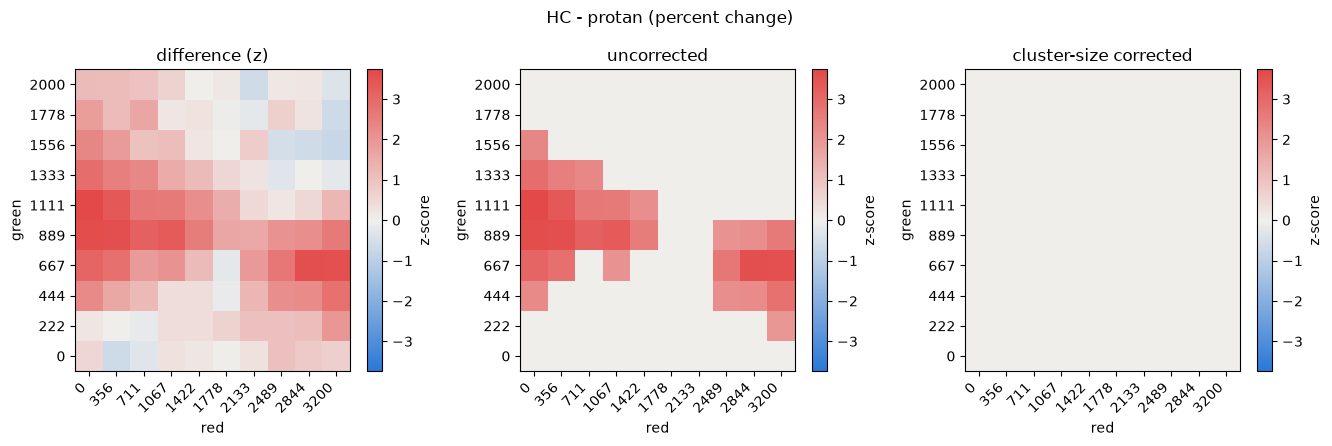

In [4]:
hc_protan = permutation.permutation_test_size(runmap_df, baselines_df, metadata_df, SESSION, group1='CTR', subgroup2='protan', normalize=analysis.DEFAULT_NORMALIZE, seed=0)
plotting.plot_permutation_test_size(hc_protan, title='HC - protan (percent change)');

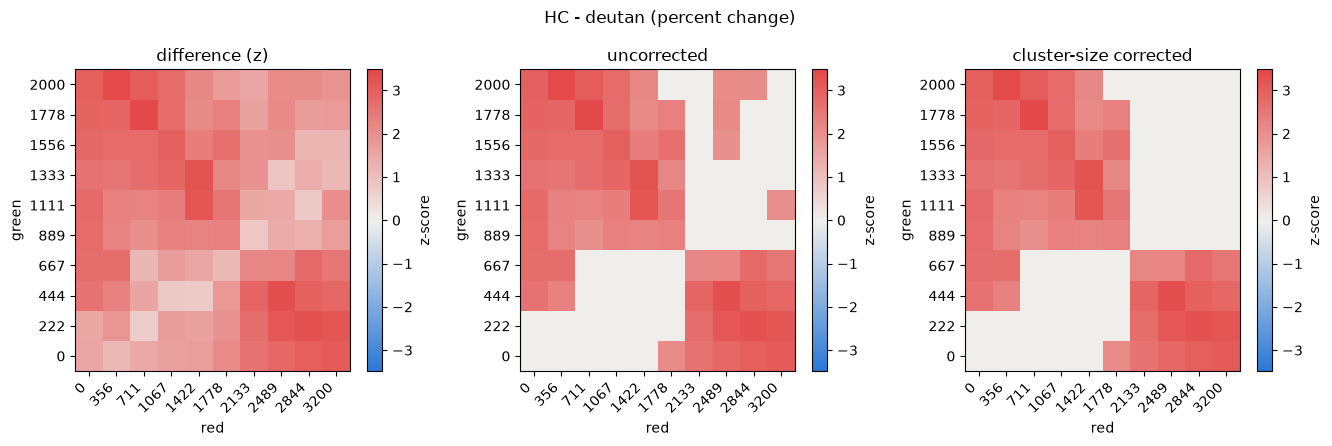

In [5]:
hc_deutan = permutation.permutation_test_size(runmap_df, baselines_df, metadata_df, SESSION, group1='CTR', subgroup2='deutan', normalize=analysis.DEFAULT_NORMALIZE, seed=0)
plotting.plot_permutation_test_size(hc_deutan, title='HC - deutan (percent change)');

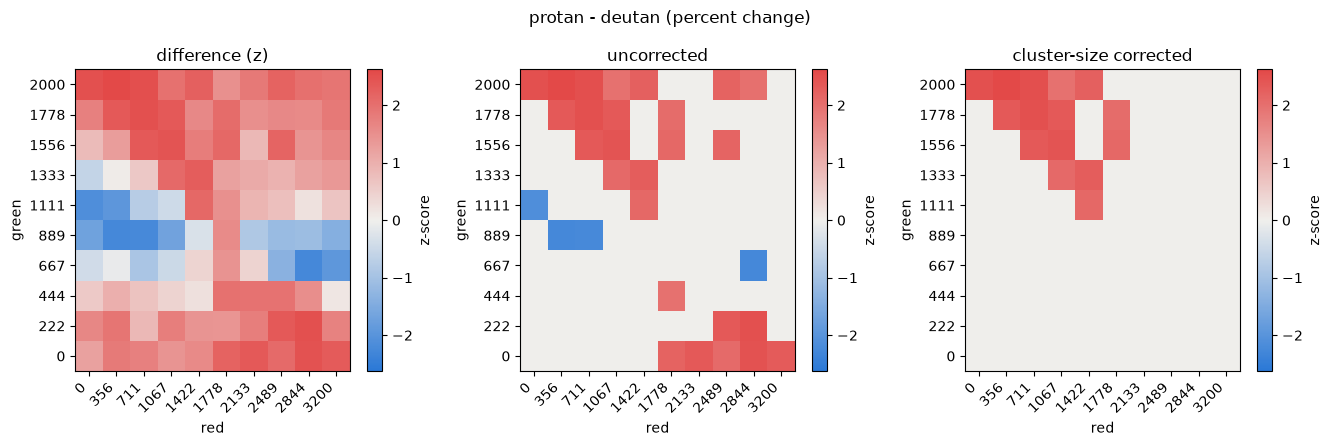

In [6]:
protan_deutan = permutation.permutation_test_size(runmap_df, baselines_df, metadata_df, SESSION, subgroup1='protan', subgroup2='deutan', normalize=analysis.DEFAULT_NORMALIZE, seed=0)
plotting.plot_permutation_test_size(protan_deutan, title='protan - deutan (percent change)');

## Boxplots and statistical comparison

Subject-level `ramp_slope_red`, three pairwise Mann-Whitney U tests -- uncorrected, matching `beh/`'s own M1 convention for its five pairwise group comparisons (no multiple-comparison correction machinery introduced inconsistently for just three tests here).

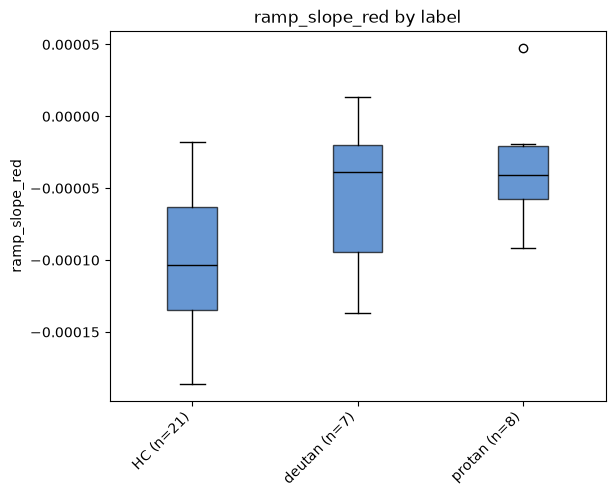

In [7]:
def _label(row):
    if row['group'] == 'CTR':
        return 'HC'
    if row['subgroup'] in ('protan', 'deutan'):
        return row['subgroup']
    return None

subtypes = troughs_df[troughs_df['session'] == SESSION].copy()
subtypes['label'] = subtypes.apply(_label, axis=1)
subtypes = subtypes.dropna(subset=['label'])
plotting.plot_troughs_boxplot(subtypes, 'ramp_slope_red', 'label', ylabel='ramp_slope_red');

In [8]:
hc_vals = subtypes.loc[subtypes['label'] == 'HC', 'ramp_slope_red']
protan_vals = subtypes.loc[subtypes['label'] == 'protan', 'ramp_slope_red']
deutan_vals = subtypes.loc[subtypes['label'] == 'deutan', 'ramp_slope_red']

pd.concat([
    pg.mwu(hc_vals, protan_vals).assign(comparison='HC vs protan'),
    pg.mwu(hc_vals, deutan_vals).assign(comparison='HC vs deutan'),
    pg.mwu(protan_vals, deutan_vals).assign(comparison='protan vs deutan'),
], ignore_index=True)

,U_val,alternative,p_val,RBC,CLES,comparison
0,23.0,two-sided,0.001875,-0.726190,0.136905,HC vs protan
1,36.0,two-sided,0.047946,-0.510204,0.244898,HC vs deutan
2,32.0,two-sided,0.694328,0.142857,0.571429,protan vs deutan


**Pixel-level, descriptive only** -- same caveat as `13_hc_vs_pd.ipynb`.

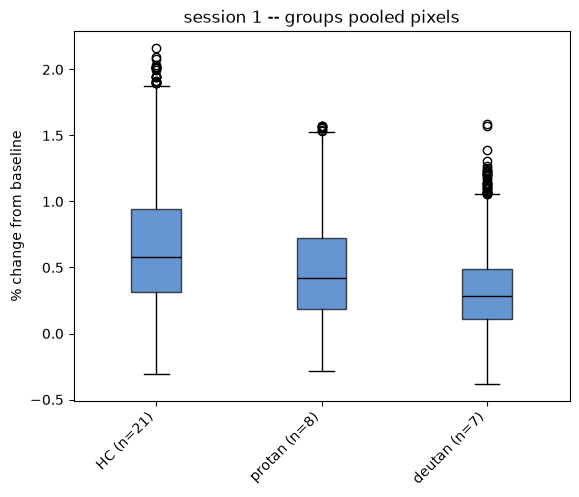

In [9]:
plotting.plot_groups_pooled_boxplot(runmap_df, baselines_df, metadata_df, SESSION, categories, normalize=analysis.DEFAULT_NORMALIZE);

## Summary

Session 1, `ramp_slope_red` Mann-Whitney: **HC vs. protan is significant** (U=23, p=0.0019, RBC=-0.73), **HC vs. deutan is significant** (U=36, p=0.048, RBC=-0.51), **protan vs. deutan is not** (U=32, p=0.69, RBC=0.14) -- matching M6's earlier report on the same measure almost exactly. Both subtypes separate cleanly from HC on this measure; they don't separate from *each other* on it. See `15_permutation_stability.ipynb` for why that's not the whole story -- the grid-level permutation test finds a robust, spatially localized protan-vs-deutan difference that this single scalar summary misses.